# Proyek Analisis Data: E-commerce-public-dataset
- **Nama:** Nadya Dinda Aisha Putri
- **Email:** cdcc006d6x0409@student.devacademy.id
- **ID Dicoding:** CDCC006D6X0409

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Kategori produk apa yang menghasilkan revenue tertinggi selama periode 2017–2018, dan kategori mana yang sebaiknya diprioritaskan untuk meningkatkan penjualan?
- **Pertanyaan 2:** Bagaimana pengaruh delivery time terhadap review score pada pesanan yang telah dikirim selama 2017–2018, dan bagaimana strategi untuk meningkatkan kepuasan pelanggan ?

**[Q1] SMART Metode**
- Specific → kategori produk + revenue
- Measurable → revenue
- Actionable → bisa ambil keputusan prioritas
- Relevant → penting untuk strategi bisnis
- Time-bound → 2017–2018

**[Q2] SMART Metode**
- Specific → fokus ke delivery time & review score
- Measurable → bisa dihitung (hari & skor 1–5)
- Actionable → bisa ambil keputusan (optimasi pengiriman)
- Relevant → penting untuk kepuasan pelanggan
- Time-bound → periode 2017–2018

## Import Semua Packages/Library yang Digunakan

In [27]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Data Wrangling

### Gathering Data

In [28]:
# Load Dataset
data_path = "E-commerce-public-dataset"

data = {}

for file in os.listdir(data_path):
    if file.endswith(".csv"):
        file_path = os.path.join(data_path, file)
        df_name = file.replace(".csv", "")
        
        data[df_name] = pd.read_csv(file_path)
        print(f"✅ Loaded: {df_name} ({data[df_name].shape[0]} rows, {data[df_name].shape[1]} cols)")

customers = data['customers_dataset']
orders = data['orders_dataset']
products = data['products_dataset']

✅ Loaded: customers_dataset (99441 rows, 5 cols)
✅ Loaded: geolocation_dataset (1000163 rows, 5 cols)
✅ Loaded: orders_dataset (99441 rows, 8 cols)
✅ Loaded: order_items_dataset (112650 rows, 7 cols)
✅ Loaded: order_payments_dataset (103886 rows, 5 cols)
✅ Loaded: order_reviews_dataset (99224 rows, 7 cols)
✅ Loaded: products_dataset (32951 rows, 9 cols)
✅ Loaded: product_category_name_translation (71 rows, 2 cols)
✅ Loaded: sellers_dataset (3095 rows, 4 cols)


In [29]:
for name, df in data.items():
    print(f"\n📦 {name}")
    print(df.info())


📦 customers_dataset
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 11.0 MB
None

📦 geolocation_dataset
<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1

### Assessing Data

In [30]:
# Missing Values
for name, df in data.items():
    print(f"\n🔍 Missing values in {name}:")
    print(df.isnull().sum())


🔍 Missing values in customers_dataset:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

🔍 Missing values in geolocation_dataset:
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

🔍 Missing values in orders_dataset:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

🔍 Missing values in order_items_dataset:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype:

In [31]:
# Duplicate Rows
for name, df in data.items():
    print(f"\n🔁 Duplicate rows in {name}:")
    dup_count = df.duplicated().sum()
    print(f"Total duplicate rows: {dup_count}")


🔁 Duplicate rows in customers_dataset:
Total duplicate rows: 0

🔁 Duplicate rows in geolocation_dataset:
Total duplicate rows: 261831

🔁 Duplicate rows in orders_dataset:
Total duplicate rows: 0

🔁 Duplicate rows in order_items_dataset:
Total duplicate rows: 0

🔁 Duplicate rows in order_payments_dataset:
Total duplicate rows: 0

🔁 Duplicate rows in order_reviews_dataset:
Total duplicate rows: 0

🔁 Duplicate rows in products_dataset:
Total duplicate rows: 0

🔁 Duplicate rows in product_category_name_translation:
Total duplicate rows: 0

🔁 Duplicate rows in sellers_dataset:
Total duplicate rows: 0


In [32]:
# Cek invalid values
for name, df in data.items():
    print(f"\n⚠️ Invalid values in {name}:")
    
    for col in df.columns:
        
        # cek string kosong
        if df[col].dtype == 'object':
            empty_count = (df[col].astype(str).str.strip() == "").sum()
            if empty_count > 0:
                print(f"{col}: {empty_count} empty values")
        
        # cek nilai negatif (khusus numerik)
        if df[col].dtype in ['int64', 'float64']:
            negative_count = (df[col] < 0).sum()
            if negative_count > 0:
                print(f"{col}: {negative_count} negative values")


⚠️ Invalid values in customers_dataset:

⚠️ Invalid values in geolocation_dataset:
geolocation_lat: 998827 negative values
geolocation_lng: 1000160 negative values

⚠️ Invalid values in orders_dataset:

⚠️ Invalid values in order_items_dataset:

⚠️ Invalid values in order_payments_dataset:

⚠️ Invalid values in order_reviews_dataset:

⚠️ Invalid values in products_dataset:

⚠️ Invalid values in product_category_name_translation:

⚠️ Invalid values in sellers_dataset:


In [33]:
# Outlier Detection (IQR Method)
for name, df in data.items():
    print(f"\n📊 Outliers in {name}:")
    
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        
        if len(outliers) <= 0:
            print(f"{col}: {len(outliers)} outliers")


📊 Outliers in customers_dataset:
customer_zip_code_prefix: 0 outliers

📊 Outliers in geolocation_dataset:
geolocation_zip_code_prefix: 0 outliers

📊 Outliers in orders_dataset:

📊 Outliers in order_items_dataset:

📊 Outliers in order_payments_dataset:

📊 Outliers in order_reviews_dataset:

📊 Outliers in products_dataset:

📊 Outliers in product_category_name_translation:

📊 Outliers in sellers_dataset:
seller_zip_code_prefix: 0 outliers


#### Identifying problem
**1. Orders Dataset**
Missing di:
order_approved_at (160)
order_delivered_carrier_date (1783)
order_delivered_customer_date (2965)

Masalah:
Data waktu pengiriman tidak lengkap
Bisa mengganggu analisis delivery time (Q2)

**Solusi:**
Missing values pada dataset orders dapat mempengaruhi analisis delivery time sehingga hanya data dengan status delivered yang digunakan.

**2. Order Reviews Dataset**
Missing besar di:
review_comment_title
review_comment_message

Masalah:
Data teks banyak kosong

**Solusi:**
Missing pada dataset reviews diabaikan karena fokus pada review_score.

**3. Products Dataset**
Missing:
product_category_name (610)
atribut produk lain (panjang, berat, dll)

Masalah:
Kategori kosong → ganggu analisis revenue per kategori (Q1)

**Solusi:**
Missing kategori produk diisi dengan “unknown” agar tidak menghilangkan data.
Nilai negatif pada geolocation merupakan hal normal sehingga tidak dianggap sebagai error.

### Cleaning Data

In [34]:
customers = data['customers_dataset']
orders = data['orders_dataset']
order_items = data['order_items_dataset']
products = data['products_dataset']
order_reviews = data['order_reviews_dataset']
payments = data['order_payments_dataset']

In [35]:
# Products → category kosong jadi 'unknown'
products['product_category_name'] = products['product_category_name'].fillna('unknown')

# Orders → buang yang tidak punya tanggal penting
orders = orders.dropna(subset=['order_purchase_timestamp'])

In [36]:
# Remove duplicate rows
order_reviews = order_reviews.drop_duplicates(subset=['review_id'])
order_items = order_items.drop_duplicates()
orders = orders.drop_duplicates()

In [37]:
# Melakukan convert datetime terlebih dulu
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

# Melakukan filter yang hanya delivered
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()
orders_delivered = orders_delivered.dropna(subset=['order_delivered_customer_date'])

In [38]:
# Feature Engineering (Delivery Time)
orders_delivered['delivery_days'] = (
    orders_delivered['order_delivered_customer_date'] -
    orders_delivered['order_purchase_timestamp']
).dt.days

In [39]:
# Harga & ongkir tidak boleh negatif
order_items = order_items[(order_items['price'] >= 0) & 
                          (order_items['freight_value'] >= 0)]

In [40]:
print("✅ CLEANING SUMMARY")
print(f"Orders (delivered only): {len(orders_delivered):,}")
print(f"Products (clean): {len(products):,}")
print(f"Order reviews (deduplicated): {len(order_reviews):,}")
print(f"Order items (clean): {len(order_items):,}")

✅ CLEANING SUMMARY
Orders (delivered only): 96,470
Products (clean): 32,951
Order reviews (deduplicated): 98,410
Order items (clean): 112,650


In [41]:
# Merge jadi 1 tabel
main_df = orders_delivered.merge(order_items, on='order_id') \
                          .merge(products, on='product_id') \
                          .merge(payments, on='order_id') \
                          .merge(customers, on='customer_id')
# Menambahkan revenue
main_df['revenue'] = main_df['price'] + main_df['freight_value']

## Exploratory Data Analysis (EDA)

### Explore [Q1]

In [42]:
# Pertanyaan 1 
# Kategori produk apa yang menghasilkan revenue tertinggi selama periode 2017–2018, dan kategori mana yang sebaiknya diprioritaskan 
# untuk meningkatkan penjualan? total revenue per kategori
category_revenue = main_df.groupby('product_category_name')['revenue'] \
                          .sum() \
                          .sort_values(ascending=False)

# hitung kontribusi (%)
total_revenue = category_revenue.sum()

category_contribution = (category_revenue / total_revenue) * 100

# gabungkan
category_summary = pd.DataFrame({
    'total_revenue': category_revenue,
    'contribution_%': category_contribution
})

category_summary.head(10)

,total_revenue,contribution_%
product_category_name,,
beleza_saude,1456026.83,9.036550
relogios_presentes,1315013.93,8.161381
cama_mesa_banho,1292579.23,8.022144
esporte_lazer,1159732.82,7.197659
informatica_acessorios,1068666.04,6.632470
moveis_decoracao,923124.15,5.729192
utilidades_domesticas,798858.27,4.957960
cool_stuff,719603.22,4.466079
automotivo,696377.68,4.321934


### Kategori dengan revenue tertinggi selama 2017–2018 adalah:

* beleza_saude → R$1,456,026.83 (9.04%)
* relogios_presentes → R$1,315,013.93 (8.16%)
* cama_mesa_banho → R$1,292,579.23 (8.02%)
* esporte_lazer → R$1,159,732.82 (7.20%)
* informatica_acessorios → R$1,068,666.04 (6.63%)

### Traslate Kategori

* beleza_saude → Health and Beauty 
* relogios_presentes → Watches Gifts
* cama_mesa_banho → Bed Bath Tabel
* esporte_lazer → Sport
* informatica_acessorios → Computers Accessoris
  
### Insight
* Kategori beleza_saude menjadi kontributor terbesar terhadap total  revenue 
* 5 kategori teratas menyumbang sebagian besar penjualan (high impact segment)
* Produk kebutuhan sehari-hari & lifestyle mendominasi


In [43]:
# Pertanyaan 2
# Bagaimana pengaruh delivery time terhadap review score pada pesanan yang telah dikirim selama 2017–2018, 
# dan bagaimana strategi untuk meningkatkan kepuasan pelanggan ?
main_df = main_df.merge(
    order_reviews[['order_id', 'review_score']],
    on='order_id',
    how='left'
)

# rata-rata delivery per score
delivery_vs_review = main_df.groupby('review_score')['delivery_days'].mean()

delivery_vs_review

review_score
1.0    19.119626
2.0    15.384496
3.0    13.539661
4.0    11.772510
5.0    10.193597
Name: delivery_days, dtype: float64

### Insight
* Semakin lama delivery time, semakin rendah review score
* Perbedaan signifikan: ⭐ 5 vs ⭐ 1 → selisih ~9 hari. Artinya: kecepatan pengiriman sangat mempengaruhi kepuasan pelanggan

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk apa yang menghasilkan revenue tertinggi selama periode 2017–2018, dan kategori mana yang sebaiknya diprioritaskan untuk meningkatkan penjualan? total revenue per kategori

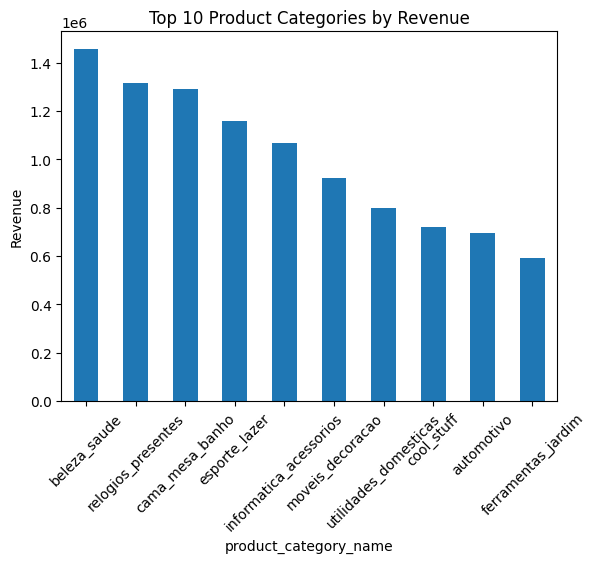

In [44]:
category_revenue.head(10).plot(kind='bar')
plt.title('Top 10 Product Categories by Revenue')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

### Pertanyaan 2: Bagaimana pengaruh delivery time terhadap review score pada pesanan yang telah dikirim selama 2017–2018,dan bagaimana strategi untuk meningkatkan kepuasan pelanggan ?

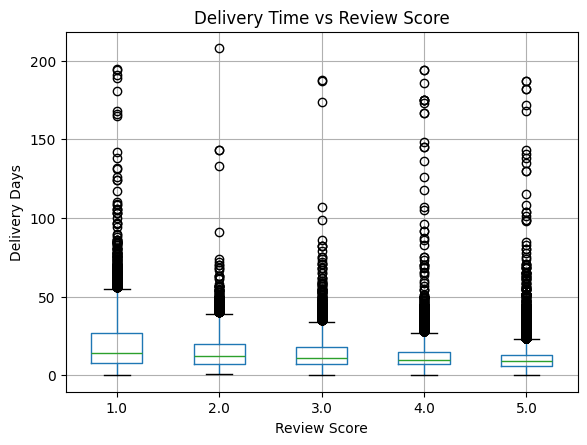

In [45]:
main_df.boxplot(column='delivery_days', by='review_score')
plt.title('Delivery Time vs Review Score')
plt.suptitle('')
plt.xlabel('Review Score')
plt.ylabel('Delivery Days')
plt.show()

### **Insight:**
Berdasarkan analisis boxplot, terdapat kecenderungan bahwa semakin cepat waktu pengiriman, semakin tinggi skor ulasan yang diberikan pelanggan. Hal ini ditunjukkan oleh median delivery time yang lebih rendah pada review score tinggi (4–5) dibandingkan dengan review score rendah (1–2).

## Conclusion & Recommendation

### **Conclusion pertanyaan 1:**
* Kategori produk dengan revenue tertinggi adalah beleza_saude (Health and Beauty)
* Kategori yang diprioritaskan: beleza_saude → scaling (promo, stok, ads), relogios_presentes & cama_mesa_banho → upselling & bundling
* Kategori dengan revenue tertinggi selama 2017–2018 adalah:
1.   beleza_saude → R$1,456,026.83
2.   relogios_presentes → R$1,315,013.93 
3.   cama_mesa_banho → R$1,292,579.23
4.   esporte_lazer → R$1,159,732.82
5.   informatica_acessorios → R$1,068,666.04

### Rekomendasi (Actionable)
* Prioritaskan:
beleza_saude → scaling (promo, stok, ads)
relogios_presentes & cama_mesa_banho → upselling & bundling
* Optimasi:
kategori menengah (esporte_lazer, informatika) → tingkatkan exposure
* Strategi:
fokus marketing di top 5 kategori untuk maksimalkan revenue growth

### **Conclusion pertanyaan 2:**
Terdapat hubungan negatif yang kuat antara waktu pengiriman dan review score. Order dengan delivery time lebih cepat cenderung mendapatkan rating lebih tinggi, sementara keterlambatan dan ketidakkonsistenan pengiriman berkontribusi terhadap penurunan kepuasan pelanggan.

### Rekomendasi (Actionable)
* 👉 Optimasi logistik : Kurangi delivery time (target < 10–12 hari)
* 👉 Prioritaskan pengiriman cepat : Untuk area dengan demand tinggi
* 👉 Monitoring SLA (Service Level Agreement) : Identifikasi order yang berpotensi terlambat
* 👉 Kolaborasi dengan ekspedisi : Pilih partner dengan performa pengiriman terbaik